PROJECT NAME:HOUSE PRICE PREDICTION
START DATE:6-2-26
END DATE:6-2-26
REGRESSION:LINEAR REGRESSION

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#to present the accuracy in the form of plot
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# Linear Regression model is used for prediction
from sklearn.metrics import mean_squared_error,r2_score
# since it is regression model accuracy score is not used 

Importing the house price dataset

In [ ]:
house_data=pd.read_csv("Housing.csv")
# importing the datset
house_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Data PreProcessing

In [13]:
house_data_new=house_data[['price','area','bedrooms','bathrooms','mainroad','hotwaterheating','airconditioning','parking','prefarea','furnishingstatus']]
# these data columns are used for the model training inorder to avoid the useless columns in between
house_data_ohe=pd.get_dummies(data=house_data_new,columns=['mainroad','hotwaterheating','airconditioning','prefarea','furnishingstatus'],drop_first=True)
# These datas are categorical datas
# It cannot read directly by the model we will convert them to '1','0',
# In the last column we have three choices furnished,unfurnished,semi furnished one will become 1 then rest two will become 0
# This art of converting the categorical data into numberical data in the specifies column is called One-Hot Encoding

In [18]:
# column segregation as input columns and output column seperately
X=house_data_ohe.drop(columns=['price'])
Y=house_data_ohe['price']
print(X.shape)
print(Y.shape)
print(X)
print(Y)

(545, 10)
(545,)
     area  bedrooms  bathrooms  parking  mainroad_yes  hotwaterheating_yes  \
0    7420         4          2        2          True                False   
1    8960         4          4        3          True                False   
2    9960         3          2        2          True                False   
3    7500         4          2        3          True                False   
4    7420         4          1        2          True                False   
..    ...       ...        ...      ...           ...                  ...   
540  3000         2          1        2          True                False   
541  2400         3          1        0         False                False   
542  3620         2          1        0          True                False   
543  2910         3          1        0         False                False   
544  3850         3          1        0          True                False   

     airconditioning_yes  prefarea_yes  furnis

Splitting of datas to train and test

In [22]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)
# stratify is used only in classification

Model training and testing

In [24]:
model=LinearRegression()
model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Model Prediction

In [28]:
prediction=model.predict(X_test)
# in regression we will have one column and it is predicted using usnseen x_test data as it is trained by x,y

Accuracy--
In classification we will use accuracy score to know the accuracy--
In regression we will use mean_squared_ error and r2_score 

In [29]:
mse=mean_squared_error(Y_test,prediction)
r2=r2_score(Y_test,prediction)
print(mse)
print(r2)

1386556603116.5464
0.6093189089257671


Presenting the actual and predicted price

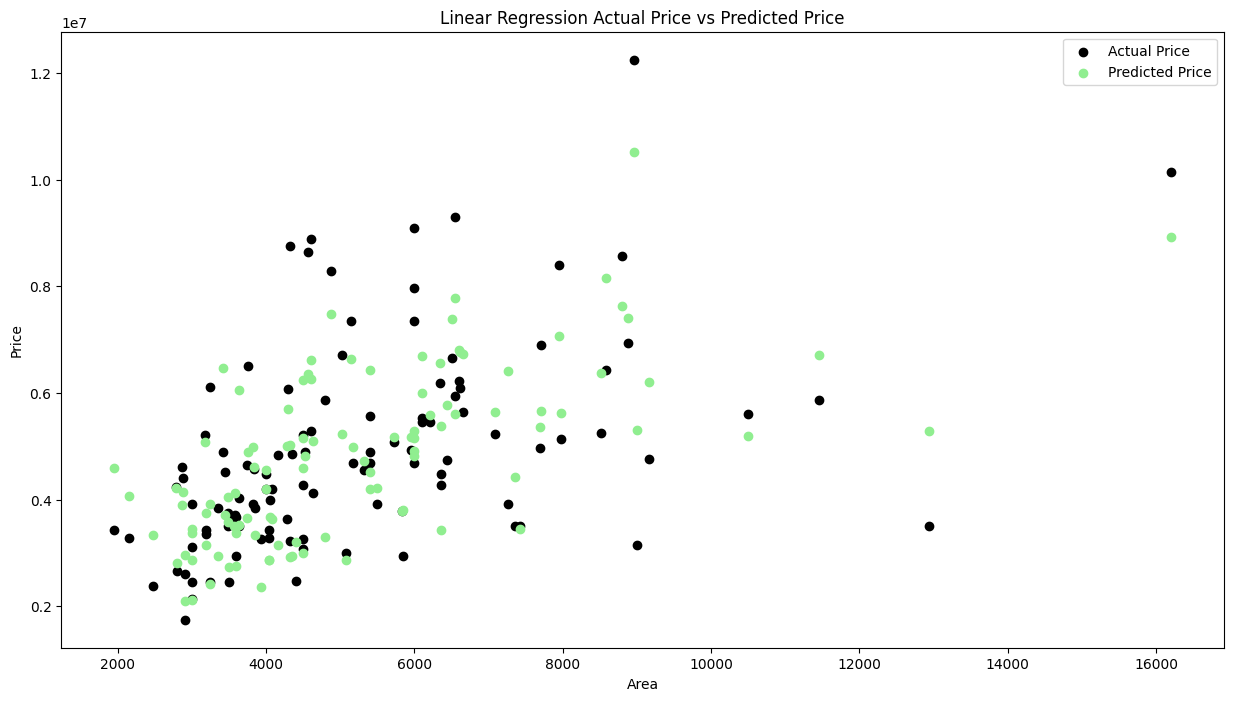

In [48]:
plt.figure(figsize=(15,8))#width and height
# comparing the original area in x_test with original price of y_test
plt.scatter(X_test['area'],Y_test,color="Black",label="Actual Price")
# comparing the original area in X_test with predicted price of y_test 
plt.scatter(X_test['area'],prediction,color="LightGreen",label="Predicted Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Linear Regression Actual Price vs Predicted Price")
plt.legend()
plt.show()